In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_excel("List_of_Orders.xlsx")
details = pd.read_excel("Order_Details.xlsx")
target = pd.read_excel("Sales_target.xlsx")

orders.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad
1,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune
2,B-25603,2018-03-04 00:00:00,Jahan,Madhya Pradesh,Bhopal
3,B-25604,2018-03-04 00:00:00,Divsha,Rajasthan,Jaipur
4,B-25605,2018-05-04 00:00:00,Kasheen,West Bengal,Kolkata


In [2]:
orders["Order Date"] = pd.to_datetime(orders["Order Date"], dayfirst=True, errors="coerce")
orders = orders.dropna(subset=["Order ID"])
details = details.dropna(subset=["Order ID"])
orders["Order Date"].head()

0   2018-01-04
1   2018-01-04
2   2018-03-04
3   2018-03-04
4   2018-05-04
Name: Order Date, dtype: datetime64[ns]

In [3]:
df = details.merge(orders, on="Order ID", how="left")
print(df.shape)
df.head()

(1500, 10)


,Order ID,Amount,Profit,Quantity,Category,Sub-Category,Order Date,CustomerName,State,City
0,B-25601,1275,-1148,7,Furniture,Bookcases,2018-01-04,Bharat,Gujarat,Ahmedabad
1,B-25601,66,-12,5,Clothing,Stole,2018-01-04,Bharat,Gujarat,Ahmedabad
2,B-25601,8,-2,3,Clothing,Hankerchief,2018-01-04,Bharat,Gujarat,Ahmedabad
3,B-25601,80,-56,4,Electronics,Electronic Games,2018-01-04,Bharat,Gujarat,Ahmedabad
4,B-25602,168,-111,2,Electronics,Phones,2018-01-04,Pearl,Maharashtra,Pune


In [4]:
cat = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Amount", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
    )
    .reset_index()
)
cat["Avg_Profit_per_Order"] = cat["Total_Profit"] / cat["Orders"]
cat["Profit_Margin_%"] = (cat["Total_Profit"] / cat["Total_Sales"] * 100).round(2)
cat.sort_values("Total_Sales", ascending=False)

,Category,Total_Sales,Total_Profit,Orders,Avg_Profit_per_Order,Profit_Margin_%
1,Electronics,165267,10494,204,51.441176,6.35
0,Clothing,139054,11163,393,28.404580,8.03
2,Furniture,127181,2298,186,12.354839,1.81


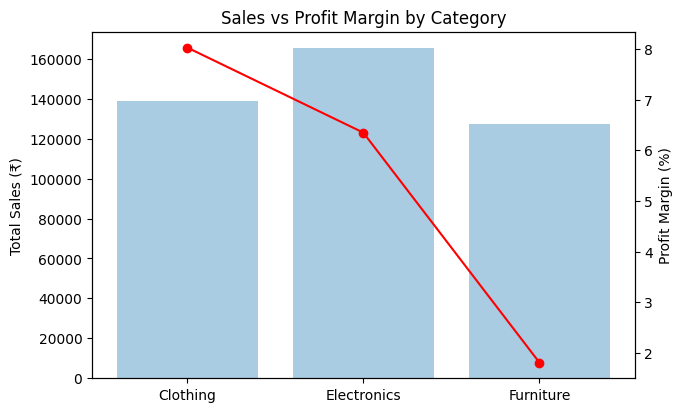

In [5]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.bar(cat["Category"], cat["Total_Sales"], color="#A9CCE3")
ax1.set_ylabel("Total Sales (₹)")

ax2 = ax1.twinx()
ax2.plot(cat["Category"], cat["Profit_Margin_%"], color="red", marker="o")
ax2.set_ylabel("Profit Margin (%)")

plt.title("Sales vs Profit Margin by Category")
plt.show()

In [6]:
target["Month of Order Date"] = pd.to_datetime(target["Month of Order Date"])

def fix_month(d):
    year = 2000 + d.day
    return pd.Timestamp(year=year, month=d.month, day=1)

target["Period"] = target["Month of Order Date"].apply(fix_month)
target.head()

,Month of Order Date,Category,Target,Period
0,2026-04-18,Furniture,10400,2018-04-01
1,2026-05-18,Furniture,10500,2018-05-01
2,2026-06-18,Furniture,10600,2018-06-01
3,2026-07-18,Furniture,10800,2018-07-01
4,2026-08-18,Furniture,10900,2018-08-01


In [7]:
furniture_target = target[target["Category"] == "Furniture"].sort_values("Period").reset_index(drop=True)
furniture_target["MoM_Change_%"] = furniture_target["Target"].pct_change().round(4) * 100
furniture_target["Month_Label"] = furniture_target["Period"].dt.strftime("%b-%Y")
furniture_target[["Month_Label", "Target", "MoM_Change_%"]]

,Month_Label,Target,MoM_Change_%
0,Apr-2018,10400,NaN
1,May-2018,10500,0.96
2,Jun-2018,10600,0.95
3,Jul-2018,10800,1.89
4,Aug-2018,10900,0.93
5,Sep-2018,11000,0.92
6,Oct-2018,11100,0.91
7,Nov-2018,11300,1.80
8,Dec-2018,11400,0.88
9,Jan-2019,11500,0.88


In [8]:
furn_actual = df[df["Category"] == "Furniture"].copy()
furn_actual["Period"] = furn_actual["Order Date"].dt.to_period("M").dt.to_timestamp()
furn_actual_m = furn_actual.groupby("Period")["Amount"].sum().reset_index(name="Actual")

furn_compare = furniture_target.merge(furn_actual_m, on="Period", how="left")
furn_compare["Achievement_%"] = (furn_compare["Actual"] / furn_compare["Target"] * 100).round(1)
furn_compare[["Month_Label", "Target", "Actual", "Achievement_%"]]

,Month_Label,Target,Actual,Achievement_%
0,Apr-2018,10400,6570,63.2
1,May-2018,10500,4677,44.5
2,Jun-2018,10600,3622,34.2
3,Jul-2018,10800,5249,48.6
4,Aug-2018,10900,15259,140.0
5,Sep-2018,11000,6728,61.2
6,Oct-2018,11100,5460,49.2
7,Nov-2018,11300,12465,110.3
8,Dec-2018,11400,6208,54.5
9,Jan-2019,11500,15944,138.6


In [9]:
state_orders = orders.groupby("State")["Order ID"].nunique().reset_index(name="Order_Count")
top5_states = state_orders.sort_values("Order_Count", ascending=False).head(5)["State"].tolist()
print(top5_states)

state_perf = (
    df[df["State"].isin(top5_states)]
    .groupby("State")
    .agg(Order_Count=("Order ID", "nunique"), Total_Sales=("Amount", "sum"), Total_Profit=("Profit", "sum"))
    .reset_index()
)
state_perf["Avg_Profit_per_Order"] = (state_perf["Total_Profit"] / state_perf["Order_Count"]).round(2)
state_perf.sort_values("Order_Count", ascending=False)

['Madhya Pradesh', 'Maharashtra', 'Rajasthan', 'Gujarat', 'Punjab']


,State,Order_Count,Total_Sales,Total_Profit,Avg_Profit_per_Order
1,Madhya Pradesh,101,105140,5551,54.96
2,Maharashtra,90,95348,6176,68.62
4,Rajasthan,32,21149,1257,39.28
0,Gujarat,27,21058,465,17.22
3,Punjab,25,16786,-609,-24.36


In [10]:
city_perf = (
    df[df["State"].isin(top5_states)]
    .groupby(["State", "City"])
    .agg(Order_Count=("Order ID", "nunique"), Total_Sales=("Amount", "sum"), Total_Profit=("Profit", "sum"))
    .reset_index()
)
city_perf["Profit_Margin_%"] = (city_perf["Total_Profit"] / city_perf["Total_Sales"] * 100).round(2)
city_perf.sort_values(["State", "Total_Sales"], ascending=[True, False])

,State,City,Order_Count,Total_Sales,Total_Profit,Profit_Margin_%
0,Gujarat,Ahmedabad,17,14230,-880,-6.18
1,Gujarat,Surat,10,6828,1345,19.70
4,Madhya Pradesh,Indore,76,79069,4159,5.26
2,Madhya Pradesh,Bhopal,22,23583,871,3.69
3,Madhya Pradesh,Delhi,3,2488,521,20.94
5,Maharashtra,Mumbai,68,61867,1637,2.65
6,Maharashtra,Pune,22,33481,4539,13.56
8,Punjab,Chandigarh,16,12279,-1153,-9.39
7,Punjab,Amritsar,9,4507,544,12.07
10,Rajasthan,Udaipur,13,11073,2010,18.15
